In [5]:
import os
import pandas as pd
import glob
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [6]:
os.chdir("C:\\Users\\willu\\OneDrive\\Dokumenter\\Microbiology PgT\\Advanced Biotech\\Computation report files")

In [7]:
os.getcwd()

'C:\\Users\\willu\\OneDrive\\Dokumenter\\Microbiology PgT\\Advanced Biotech\\Computation report files'

In [8]:
folder_path = "C:\\Users\willu\\OneDrive\\Dokumenter\Microbiology PgT\\Advanced Biotech\\Computation report files"

In [9]:
files = glob.glob(os.path.join(folder_path, "*.txt"))

In [10]:
df_list = []

for file in files:
    df = pd.read_csv(file, sep="\t")
    df["Source_File"] = os.path.basename(file)
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.head())

print("Rows, Columns:", combined_df.shape)

      Gene                                  WildType.Sequence  \
0      Ah3  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...   
1    Alli8  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...   
2  Anap7c1  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...   
3   App1l8  ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...   
4    Avon4  TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...   

                                     Mutant.Sequence  mRNA.Expression.WT.Rep1  \
0  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...                31.831346   
1  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...                63.891354   
2  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...                 1.629126   
3  ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...                 3.619328   
4  TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...                 1.398400   

   mRNA.Expression.WT.Rep2  mRNA.Expression.WT.Rep3  mRNA.Expression.Mut.Rep1  \
0                26.177081               

In [49]:
combined_df["CellViability_WT_Mean"] = combined_df[
    [
        "CellViability.WT.Rep1",
        "CellViability.WT.Rep2",
        "CellViability.WT.Rep3"
    ]
].mean(axis=1)

combined_df["CellViability_Mut_Mean"] = combined_df[
    [
        "CellViability.Mut.Rep1",
        "CellViability.Mut.Rep2",
        "CellViability.Mut.Rep3"
    ]
].mean(axis=1)

combined_df["Viability_Difference"] = (
    combined_df["CellViability_Mut_Mean"] -
    combined_df["CellViability_WT_Mean"]
) # Negative results = reduced Viability, Positive results = increased Viability

pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["CellViability.WT.Rep1"],
        row["CellViability.WT.Rep2"],
        row["CellViability.WT.Rep3"]
    ]

    mut = [
        row["CellViability.Mut.Rep1"],
        row["CellViability.Mut.Rep2"],
        row["CellViability.Mut.Rep3"]
    ]

    pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["CellViability.WT.Rep1"],
        row["CellViability.WT.Rep2"],
        row["CellViability.WT.Rep3"]
    ]

    mut = [
        row["CellViability.Mut.Rep1"],
        row["CellViability.Mut.Rep2"],
        row["CellViability.Mut.Rep3"]
    ]

    stat, p = ttest_ind(wt, mut)
    pvals.append(p)

combined_df["p_value"] = pvals

combined_df["Significant Increase"] = combined_df["p_value"] < 0.05
combined_df["Not Significant"] = combined_df["p_value"] > 0.05

plot_df = combined_df.sort_values("Viability_Difference")

In [50]:
combined_df["mRNAExpression_WT_Mean"] = combined_df[
    [
        "mRNA.Expression.WT.Rep1",
        "mRNA.Expression.WT.Rep2",
        "mRNA.Expression.WT.Rep3"
    ]
].mean(axis=1)

combined_df["mRNAExpression_Mut_Mean"] = combined_df[
    [
        "mRNA.Expression.Mut.Rep1",
        "mRNA.Expression.Mut.Rep2",
        "mRNA.Expression.Mut.Rep3"
    ]
].mean(axis=1)

combined_df["mRNA_Expression_Difference"] = (
    combined_df["mRNAExpression_Mut_Mean"] -
    combined_df["mRNAExpression_WT_Mean"]
)

pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["mRNA.Expression.WT.Rep1"],
        row["mRNA.Expression.WT.Rep2"],
        row["mRNA.Expression.WT.Rep3"]
    ]

    mut = [
        row["mRNA.Expression.Mut.Rep1"],
        row["mRNA.Expression.Mut.Rep2"],
        row["mRNA.Expression.Mut.Rep3"]
    ]

    stat, p = ttest_ind(wt, mut)
    pvals.append(p)

combined_df["p_value"] = pvals

combined_df["Significant"] = combined_df["p_value"] < 0.05

plot_df = combined_df.sort_values("mRNA_Expression_Difference")

In [51]:
combined_df["ProteinExpression_WT_Mean"] = combined_df[
    [
        "Protein.Expression.WT.Rep1",
        "Protein.Expression.WT.Rep2",
        "Protein.Expression.WT.Rep3"
    ]
].mean(axis=1)

combined_df["ProteinExpression_Mut_Mean"] = combined_df[
    [
        "Protein.Expression.Mut.Rep1",
        "Protein.Expression.Mut.Rep2",
        "Protein.Expression.Mut.Rep3"
    ]
].mean(axis=1)

combined_df["Protein_Expression_Difference"] = (
    combined_df["ProteinExpression_Mut_Mean"] -
    combined_df["ProteinExpression_WT_Mean"]
)

pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["Protein.Expression.WT.Rep1"],
        row["Protein.Expression.WT.Rep2"],
        row["Protein.Expression.WT.Rep3"]
    ]

    mut = [
        row["Protein.Expression.Mut.Rep1"],
        row["Protein.Expression.Mut.Rep2"],
        row["Protein.Expression.Mut.Rep3"]
    ]

    stat, p = ttest_ind(wt, mut)
    pvals.append(p)

combined_df["p_value"] = pvals

combined_df["Significant"] = combined_df["p_value"] < 0.05

plot_df = combined_df.sort_values("Protein_Expression_Difference")

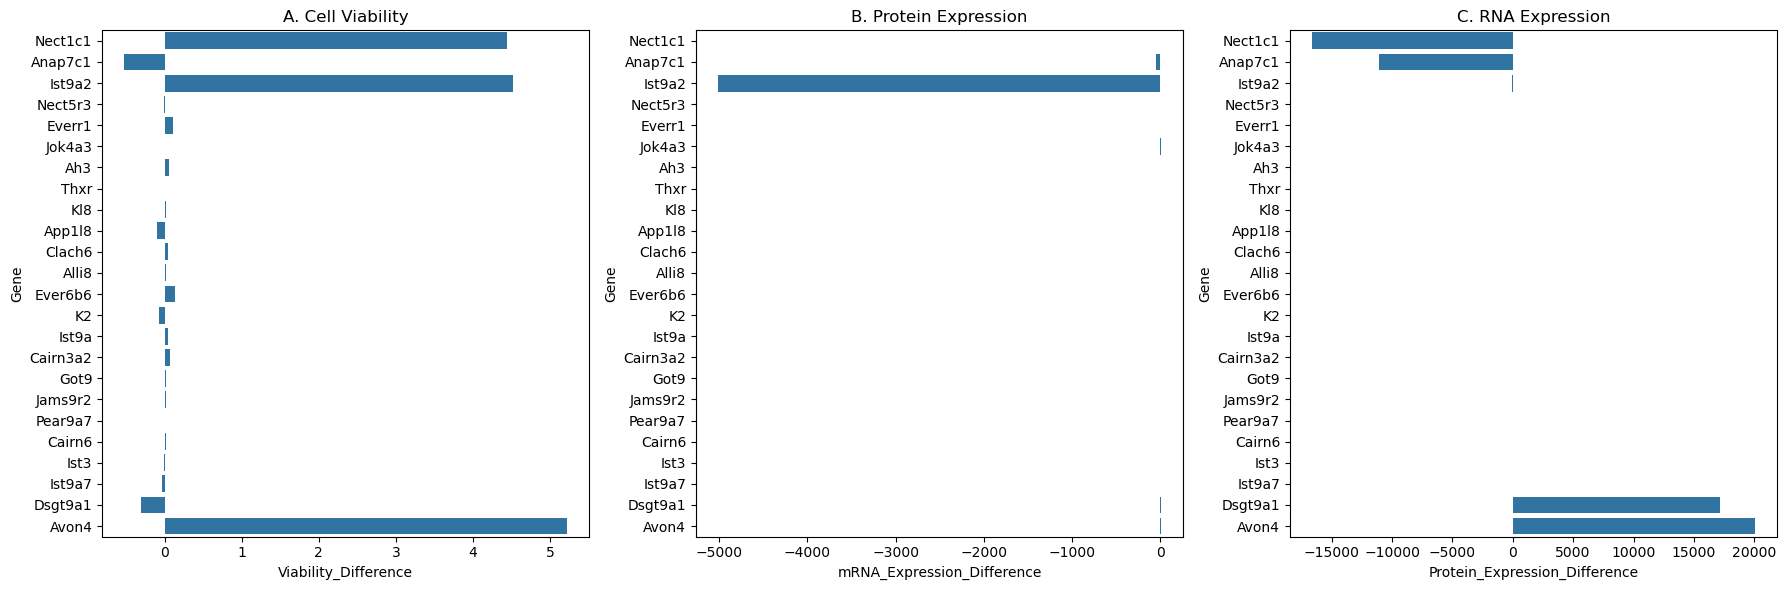

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.barplot(
    data=plot_df,
    x="Viability_Difference",
    y="Gene",
    ax=axes[0]
)
axes[0].set_title("A. Cell Viability")

sns.barplot(
    data=plot_df,
    x="mRNA_Expression_Difference",
    y="Gene",
    ax=axes[1]
)
axes[1].set_title("B. Protein Expression")

sns.barplot(
    data=plot_df,
    x="Protein_Expression_Difference",
    y="Gene",
    ax=axes[2]
)
axes[2].set_title("C. RNA Expression")

plt.tight_layout()
plt.show()